### Looking at 2024_12_10 ALD data LOW TEMP


In [1]:
# Imports and initializaion
import numpy as np
import matplotlib.pyplot as plt
import spe_loader as sl
import scipy as sp
import scipy.constants as sc
import glob
from scipy.stats import norm
import pandas as pd
from scipy.optimize import curve_fit
import sys
sys.path.append('..')
from spefile3 import *
from read_qdlscope import *

Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
30.0
Successfully loaded 1 file(s) in a SpeFile object
10.0


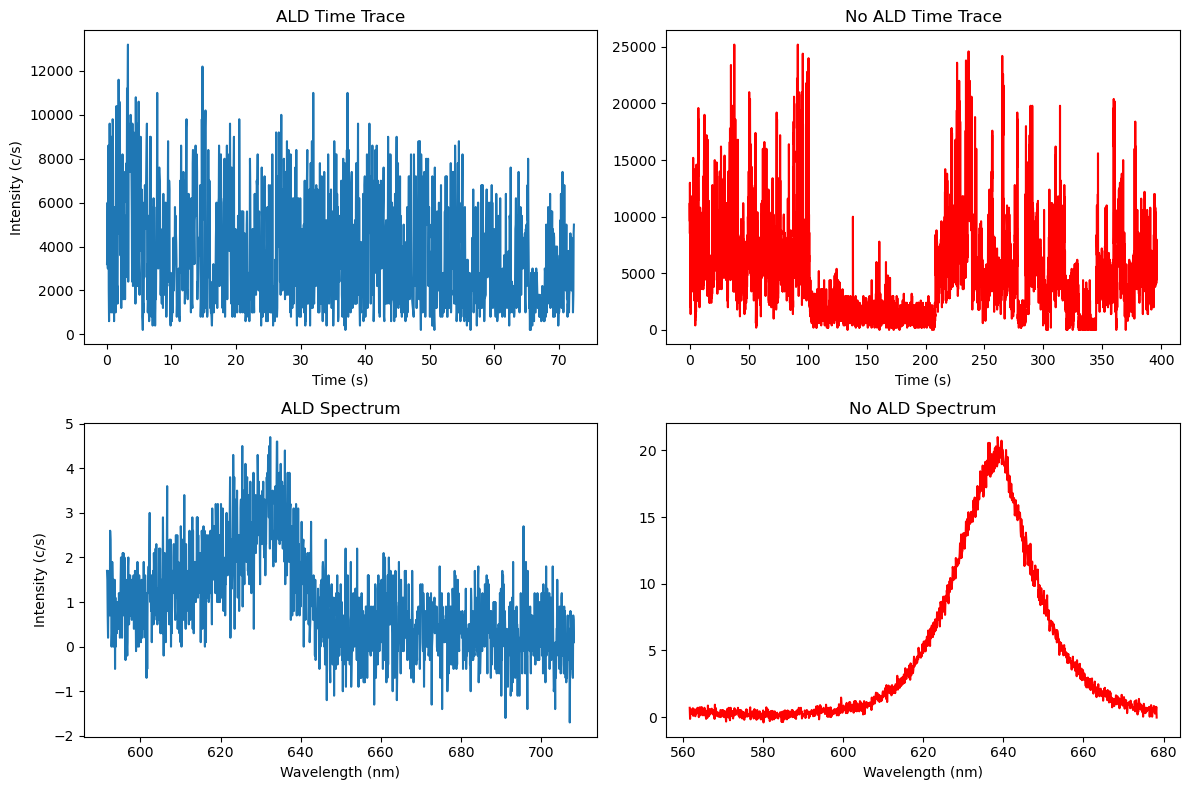

In [44]:
# 3uW was used for all data

fig, ax = plt.subplots(2, 2, figsize=(12,8))

# FOR TIME TRACES
dot11_timetrace = readQDLScope('/Users/tommtommbom/Desktop/qdrepos/hdf5Data/2024/2024_12_10/dot11.hdf5') # ALD 
ax[0,0].plot(dot11_timetrace.timestamps, dot11_timetrace.intensity, label='ALD')
ax[0,0].set_title('ALD Time Trace') 
ax[0,0].set_xlabel('Time (s)')
ax[0,0].set_ylabel('Intensity (c/s)')
dot9_timetrace = readQDLScope('/Users/tommtommbom/Desktop/qdrepos/hdf5Data/2024/2024_12_10/dot9.hdf5') # SiO2
ax[0,1].plot(dot9_timetrace.timestamps, dot9_timetrace.intensity,'r', label='SiO2')
ax[0,1].set_title('No ALD Time Trace')
ax[0,1].set_xlabel('Time (s)')

# FOR SPECTRA
bkg_spec = speFile3('/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_07/ald/bkg_10 2024 December 10 12_46_22.spe')
bkgx = bkg_spec.wavelengths
bkgy = bkg_spec.data[0][0][0]
bkgy = bkgy.astype(float)
# sio2 
dot8_spectra = speFile3('/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_07/sio2/3uW_10sec_620center_300groove_dot8 2024 December 10 16_24_15.spe')
d8x = dot8_spectra.wavelengths
d8y = dot8_spectra.data[0][0][0]
d8y = d8y.astype(float)
d8y = (d8y - bkgy)/dot8_spectra.exposure
print(dot8_spectra.exposure)
# ald
dot9_spectra = speFile3('/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_07/ald/3uW_10sec_650center_300groove_dot9 2024 December 10 13_39_04.spe')
d9x = dot9_spectra.wavelengths
d9y = dot9_spectra.data[0][0][0]/dot9_spectra.exposure
print(dot9_spectra.exposure)

ax[1,0].plot(d9x, d9y, label='ALD_spec')
ax[1,0].set_title('ALD Spectrum')
ax[1,0].set_xlabel('Wavelength (nm)')
ax[1,0].set_ylabel('Intensity (c/s)')
ax[1,1].plot(d8x, d8y, 'r', label='SiO2_spec')
ax[1,1].set_title('No ALD Spectrum')
ax[1,1].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.show()



Comparing blinking rate

Number of crossings: 154
Number of crossings: 95


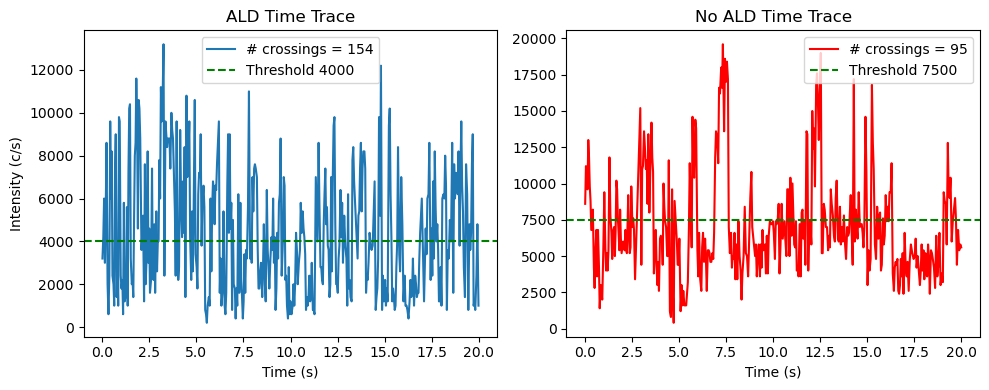

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
timeIndex = 20
crossings = np.sum(np.diff(dot11_timetrace.intensity[dot11_timetrace.timestamps <= timeIndex] > 4000) > 0)
crossings2 = np.sum(np.diff(dot9_timetrace.intensity[dot9_timetrace.timestamps <= timeIndex] > 7500) > 0)
print(f"Number of crossings: {crossings}")
print(f"Number of crossings: {crossings2}")
ax[0].plot(dot11_timetrace.timestamps[dot11_timetrace.timestamps <= timeIndex], 
           dot11_timetrace.intensity[dot11_timetrace.timestamps <= timeIndex], label=f'# crossings = {crossings}')
ax[0].set_title('ALD Time Trace') 
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Intensity (c/s)')
ax[0].axhline(y=4000, color='g', linestyle='--', label='Threshold 4000')
ax[0].legend()
ax[1].plot(dot9_timetrace.timestamps[dot9_timetrace.timestamps <= timeIndex], 
           dot9_timetrace.intensity[dot9_timetrace.timestamps <= timeIndex], 'r', label=f'# crossings = {crossings2}')
ax[1].axhline(y=7500, color='g', linestyle='--', label='Threshold 7500')

ax[1].set_title('No ALD Time Trace')
ax[1].set_xlabel('Time (s)')
ax[1].legend()
plt.tight_layout()
plt.show()

In [30]:
np.diff(dot11_timetrace.intensity > 5000)[:10]

array([False,  True,  True,  True, False,  True, False, False,  True,
       False])

In [26]:
True - True

0